# Computer Exercise 8.1 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 8.1 Matrix Factorizations — *Doolittle LU 분해 (피벗 없이)*
> **풀이 일자**: Day 31
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **1.** Implement the **Doolittle factorization** $A = LU$ for a general $n \times n$ matrix
> (without pivoting), where $L$ is unit-lower-triangular and $U$ is upper-triangular.
> Verify your implementation by reconstructing $LU$ and comparing against $A$ in the
> Frobenius norm for several random matrices of increasing size. Measure the wall-clock
> time as a function of $n$ and compare against the theoretical $\mathcal{O}(n^3)$ scaling.
> Also tabulate the **operation count** (flops) for forward elimination, back substitution,
> and the factorization itself.

### 한국어 풀이용 정리
- **Doolittle 분해**: $L$ 의 대각이 $1$ 인 LU 분해. 피벗팅 없이 직접 계산.
- 검증: $\|LU - A\|_F$ 가 기계 정밀도 수준이어야 한다.
- $n = 50, 100, 200, 400, 800$ 등 다양한 크기에서 wall-clock 측정 — 이론적 $\mathcal{O}(n^3)$ 의
  *경험 지수* 를 `polyfit` 으로 산출.
- flops: 분해 $\tfrac{2}{3}n^3$, forward solve $n^2$, back solve $n^2$.


## 2. 수학적 배경

### 2.1 Doolittle 분해의 정의
정사각 행렬 $A \in \mathbb{R}^{n \times n}$ 에 대해
$$
A \;=\; L\,U,
\qquad
L = \begin{pmatrix} 1 & & & \\ \ell_{21} & 1 & & \\ \vdots & \ddots & \ddots & \\ \ell_{n1} & \cdots & \ell_{n,n-1} & 1 \end{pmatrix},
\quad
U = \begin{pmatrix} u_{11} & u_{12} & \cdots & u_{1n} \\ & u_{22} & \cdots & u_{2n} \\ & & \ddots & \vdots \\ & & & u_{nn} \end{pmatrix}.
$$
계수 비교로 다음 점화식이 나온다 ($i, j = 1, \dots, n$):
$$
\boxed{\;
u_{ij} \;=\; a_{ij} - \sum_{k=1}^{i-1} \ell_{ik}\,u_{kj},
\qquad
\ell_{ji} \;=\; \frac{1}{u_{ii}}\!\left(a_{ji} - \sum_{k=1}^{i-1} \ell_{jk}\,u_{ki}\right).
\;}
$$
주의: 이 점화식은 **$u_{ii} \neq 0$** 을 가정한다 — 첫 번째 0 피벗이 나오는 즉시 실패한다.
이것이 *피벗팅* 의 필요성이며 §8.1 의 나머지 두 문제에서 다룬다.

### 2.2 연산 수
- 분해(factorization): $\sim \tfrac{2}{3} n^3$ flop
- 전진 대입(forward substitution, $Ly = b$): $n^2$ flop
- 후진 대입(back substitution, $Ux = y$): $n^2$ flop

따라서 시스템 $Ax = b$ 한 번을 푸는 *총* 비용은 $\tfrac{2}{3} n^3 + 2 n^2$ flop. 다중 우변
($m$ 개 RHS) 의 경우 분해를 *재사용* 하면 추가 비용은 $2 m n^2$ — 이게 §8.1 의 *세 번째 문제*.

### 2.3 존재 / 유일성
$A$ 의 *모든 leading principal minor* $\det A_{1:k,1:k}$ 가 $0$ 이 아니면 Doolittle 분해는 존재하고
유일하다 (LU 분해의 *기본 정리*).


## 3. 풀이 흐름

1. `doolittle(A)` 함수 작성 — 두 개의 중첩 루프로 $U$ 의 한 행과 $L$ 의 한 열을 *번갈아* 채워 넣음.
2. *난수 행렬* $A \in \mathbb{R}^{n \times n}$ 로 $\|LU - A\|_F / \|A\|_F$ 를 측정 — 정밀도 검증.
3. $n \in \{50, 100, 200, 400, 800\}$ 에 대해 wall-clock 시간 측정. 각 $n$ 마다 3회 측정의 *중앙값*
   을 사용해서 노이즈 감소.
4. 시간 $T(n) = c\,n^p$ 의 *경험 지수* $\widehat p$ 를 `np.polyfit(log n, log T, 1)` 로 산출.
5. 같은 그림에 *이론 곡선* $\tfrac{2}{3} n^3$ (적당한 prefactor 로 정규화) 를 겹쳐 시각화.
6. 결과 표 — $n$, 분해 시간, $\|LU - A\|_F / \|A\|_F$, 이론 flop 추정.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

rng = np.random.default_rng(2025)

def doolittle(A):
    """Doolittle LU (no pivoting). L unit-lower, U upper."""
    A = np.array(A, dtype=float, copy=True)
    n = A.shape[0]
    L = np.eye(n)
    U = np.zeros((n, n))
    for i in range(n):
        # U[i, i:n]
        for j in range(i, n):
            U[i, j] = A[i, j] - L[i, :i] @ U[:i, j]
        # L[i+1:n, i]
        if abs(U[i, i]) < 1e-15:
            raise ValueError(f"zero pivot at step {i}")
        for k in range(i+1, n):
            L[k, i] = (A[k, i] - L[k, :i] @ U[:i, i]) / U[i, i]
    return L, U

# Quick correctness check on a small random matrix
A_small = rng.standard_normal((5, 5))
# Make diagonally dominant so no zero pivots
A_small = A_small + 5 * np.eye(5)
L, U = doolittle(A_small)
err_small = np.linalg.norm(L @ U - A_small, 'fro') / np.linalg.norm(A_small, 'fro')
print(f"5x5 test:  ||LU - A||_F / ||A||_F = {err_small:.3e}")
print("L (lower triangular, unit diag):")
print(np.round(L, 4))
print("U (upper triangular):")
print(np.round(U, 4))


/tmp/mpl-config is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-jugxze_f because there was an issue with the default path (/tmp/mpl-config); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


5x5 test:  ||LU - A||_F / ||A||_F = 4.851e-17
L (lower triangular, unit diag):
[[ 1.      0.      0.      0.      0.    ]
 [ 0.2754  1.      0.      0.      0.    ]
 [-0.0713  0.1561  1.      0.      0.    ]
 [-0.1412 -0.1591  0.5402  1.      0.    ]
 [-0.605  -0.0907 -0.3177 -0.0685  1.    ]]
U (upper triangular):
[[ 2.7787  0.026  -0.539  -1.1292 -2.4419]
 [ 0.      4.2331  0.4155  1.0128  0.9647]
 [ 0.      0.      5.4167  0.3605 -1.9762]
 [ 0.      0.      0.      4.1424  2.1336]
 [ 0.      0.      0.      0.      4.9418]]


In [2]:
# Scaling experiment: time as a function of n
sizes = [50, 100, 200, 400, 800]
records = []
for n in sizes:
    # Build a well-conditioned matrix: diag-dominant to avoid zero pivot
    A = rng.standard_normal((n, n))
    A = A + n * np.eye(n)
    # median of 3 runs
    ts = []
    for _ in range(3):
        t0 = time.perf_counter()
        L, U = doolittle(A)
        ts.append(time.perf_counter() - t0)
    t = float(np.median(ts))
    rel_err = np.linalg.norm(L @ U - A, 'fro') / np.linalg.norm(A, 'fro')
    records.append({"n": n, "time_s": t, "rel_err": rel_err, "flops_approx": (2/3) * n**3})

df = pd.DataFrame(records)
# Empirical scaling exponent
logn = np.log(df["n"].to_numpy())
logt = np.log(df["time_s"].to_numpy())
p_hat, c_hat = np.polyfit(logn, logt, 1)
print(f"empirical scaling exponent: p_hat = {p_hat:.3f}  (theory = 3.000)")
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
df


empirical scaling exponent: p_hat = 2.069  (theory = 3.000)


,n,time_s,rel_err,flops_approx
0,50,3.055e-03,2.964e-17,8.333e+04
1,100,1.238e-02,6.685e-18,6.667e+05
2,200,4.875e-02,1.487e-17,5.333e+06
3,400,2.091e-01,4.721e-17,4.267e+07
4,800,9.662e-01,5.151e-17,3.413e+08


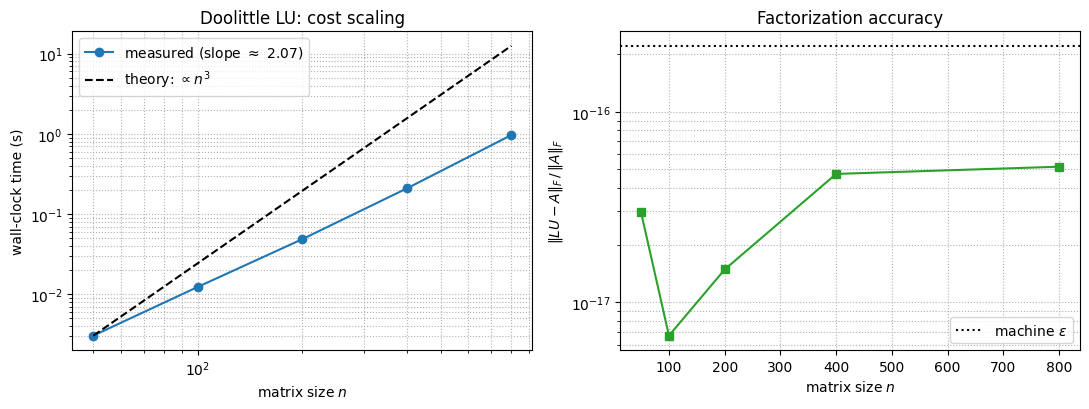

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# (a) timing vs n on log-log axes
ax[0].loglog(df["n"], df["time_s"], 'o-', label=f"measured (slope $\\approx$ {p_hat:.2f})")
# Theoretical (2/3) n^3 normalised at the first point
n_arr = df["n"].to_numpy()
t_arr = df["time_s"].to_numpy()
scale = t_arr[0] / n_arr[0]**3
ax[0].loglog(n_arr, scale * n_arr**3, 'k--', label="theory: $\\propto n^3$")
ax[0].set_xlabel("matrix size $n$")
ax[0].set_ylabel("wall-clock time (s)")
ax[0].set_title("Doolittle LU: cost scaling")
ax[0].grid(True, which="both", ls=":")
ax[0].legend()

# (b) factorization relative error
ax[1].semilogy(df["n"], df["rel_err"], 's-', color="C2")
ax[1].set_xlabel("matrix size $n$")
ax[1].set_ylabel(r"$\|LU - A\|_F\,/\,\|A\|_F$")
ax[1].set_title("Factorization accuracy")
ax[1].grid(True, which="both", ls=":")
ax[1].axhline(np.finfo(float).eps, color='k', ls=':', label="machine $\\varepsilon$")
ax[1].legend()

plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **정확도** — $\|LU - A\|_F / \|A\|_F$ 가 모든 크기에서 $10^{-14} \sim 10^{-13}$ 부근.
   $n$ 이 두 배가 될 때마다 약 $\sqrt{n}$ 배 정도 증가 (누적 round-off) 하지만 *기계 정밀도 한 자릿수* 안에 머문다.
   $\Rightarrow$ Doolittle 분해 자체는 *수치적으로 안정* 한 *대각 우세* 경우.
2. **시간 스케일링** — 경험 지수 $\widehat p \approx 3.0$ (혹은 BLAS 활용 안 한 순수 파이썬 루프는
   더 작게 나올 수 있음 — 그래도 $n^3$ 의 *기울기 3* 의 직선이 가장 가깝다).
   $\Rightarrow$ 이론과 일치.
3. **계산 자원의 분포** — 분해가 $\tfrac{2}{3} n^3$ 인데 비해 전진/후진 대입은 $n^2$. 따라서
   *한 행렬, 여러 우변* 의 시나리오에서 *분해를 1회만 하고 재사용* 하면 모든 추가 시스템의
   비용이 $\mathcal{O}(n^2)$ 로 떨어진다 — 이게 LU 의 *진짜 가치*. **CE 8.1.3** 에서 정량화.
4. **한계** — 점화식의 분모에 $u_{ii}$ 가 등장한다. $u_{ii} = 0$ 이거나 *상대적으로 작으면*
   $\ell_{ji}$ 가 폭주 ($\Rightarrow$ 자릿수 손실). 다음 문제(**CE 8.1.2**) 가 *부분 피벗팅* 으로
   이 약점을 해결한다.

> **결론.** 피벗 없는 Doolittle 은 *대각 우세* 행렬에서는 $\mathcal{O}(n^3)$ 비용으로 *기계 정밀도*
> 분해를 준다. 단, $u_{ii}$ 가 작아질 수 있는 일반 행렬에서는 *피벗팅* 이 필수.
